<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/registration-statements/top-law-firms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Most Used Law Firms During Securities Offerings (424B4)

The following example shows how to determine the top 20 most often used law firms during securities offerings from 2000 to 2024. As with previous examples, the dataframe `df` contains all extracted data from registration statements (S-1, F-1, S-11) and prospectus filings (424B4) between 2000 and 2024 and was generated using the code provided in the [Loading Large Amounts of Data](#Loading-Large-Amounts-of-Data) section.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

params = {
    "axes.labelsize": 8, "font.size": 8, "legend.fontsize": 8, "xtick.labelsize": 8,
    "ytick.labelsize": 8, "text.usetex": False, "font.family": "sans-serif", "axes.spines.top": False,
    "axes.spines.right": False, "grid.color": "grey", "axes.grid": True, "grid.alpha": 0.5,
    "grid.linestyle": ":", "axes.grid.axis": "y", "axes.axisbelow": True,
}

plt.rcParams.update(params)

In [ ]:
df.head()

,filedAt,accessionNo,formType,cik,ticker,entityName,filingUrl,tickers,securities,publicOfferingPrice,underwritingDiscount,proceedsBeforeExpenses,underwriters,lawFirms,auditors,management,employees
0,2000-01-04 00:00:00-05:00,0000950133-00-000008,S-1/A,1069502,VSTY,VARSITYBOOKS COM INC,https://www.sec.gov/Archives/edgar/data/106950...,"[{'ticker': 'VSTY', 'type': 'Common Stock', 'e...",[],{},{},{},[{'name': 'FleetBoston Robertson Stephens Inc....,"[{'name': 'Shaw Pittman', 'location': 'Virgini...","[{'name': 'PricewaterhouseCoopers LLP'}, {'nam...","[{'name': 'Eric J. Kuhn', 'age': 29, 'position...","{'total': 153, 'asOfDate': '1999-12-31', 'perD..."
1,2000-01-07 00:00:00-05:00,0000950133-00-000038,S-1/A,1035096,WEBM,WEBMETHODS INC,https://www.sec.gov/Archives/edgar/data/103509...,"[{'ticker': 'WEBM', 'type': 'Common Stock', 'e...",[{'name': 'shares of common stock'}],{},{},{},"[{'name': 'Morgan Stanley & Co.'}, {'name': 'D...","[{'name': 'Shaw Pittman', 'location': 'Virgini...",[{'name': 'PricewaterhouseCoopers LLP'}],"[{'name': 'Phillip Merrick', 'age': 37, 'posit...","{'total': 150, 'asOfDate': '1999-10-31', 'perD..."
2,2000-01-12 00:00:00-05:00,0000950133-00-000048,S-1/A,1099160,BBGI,BEASLEY BROADCAST GROUP INC,https://www.sec.gov/Archives/edgar/data/109916...,"[{'ticker': 'BBGI', 'type': 'Class A Common St...","[{'name': '6,850,000 Shares Class A Common Sto...",{},{},{},[{'name': 'Credit Suisse First Boston Corporat...,"[{'name': 'Latham & Watkins', 'location': 'Was...",[{'name': 'KPMG LLP'}],"[{'name': 'George G. Beasley', 'age': 67, 'pos...","{'total': 565, 'asOfDate': '1999-12-25', 'perD..."
3,2000-01-12 00:00:00-05:00,0000950131-00-000138,S-1/A,1100370,LNTE,LANTE CORP,https://www.sec.gov/Archives/edgar/data/110037...,"[{'ticker': 'LNTE', 'type': 'Common Stock', 'e...",[],{},{},{},[{'name': 'Credit Suisse First Boston Corporat...,"[{'name': 'Katten Muchin Zavis', 'location': '...",[{'name': 'PricewaterhouseCoopers LLP'}],"[{'name': 'Mark Tebbe', 'age': 38, 'position':...","{'total': 344, 'asOfDate': '1999-12-31', 'perD..."
4,2000-01-12 00:00:00-05:00,0000912057-00-000928,S-1/A,1098834,FRGO,FARGO ELECTRONICS INC,https://www.sec.gov/Archives/edgar/data/109883...,"[{'ticker': 'FRGO', 'type': 'Common Stock', 'e...","[{'name': '5,000,000 Shares Common Stock'}]",{},{},{},[{'name': 'Prudential Securities Incorporated'...,"[{'name': 'Oppenheimer Wolff & Donnelly LLP', ...","[{'name': 'PricewaterhouseCoopers LLP'}, {'nam...","[{'name': 'Gary R. Holland', 'age': 57, 'posit...","{'total': 165, 'asOfDate': '1999-09-30', 'perD..."


In [ ]:
df_lawfirms = df[df['formType'] == '424B4'][["filedAt", "accessionNo", "lawFirms"]].copy()
df_lawfirms = df_lawfirms.explode("lawFirms")
df_lawfirms["lawFirmName"] = df_lawfirms["lawFirms"].apply(
    lambda d: d["name"].upper()
    if isinstance(d, dict) and "name" in d and d["name"] is not None
    else None
)
df_lawfirms["lawFirmLocation"] = df_lawfirms["lawFirms"].apply(lambda d: d["location"] if isinstance(d, dict) and "location" in d else None)
df_lawfirms.drop_duplicates(subset=["accessionNo", "lawFirmName"], inplace=True)
df_lawfirms.head()

,filedAt,accessionNo,lawFirms,lawFirmName,lawFirmLocation
8,2000-01-25 00:00:00-05:00,0000950152-00-000338,"{'name': 'Strauss & Troy, a Legal Professional...","STRAUSS & TROY, A LEGAL PROFESSIONAL ASSOCIATION","Ohio, USA"
8,2000-01-25 00:00:00-05:00,0000950152-00-000338,"{'name': 'Shearman & Sterling', 'location': 'N...",SHEARMAN & STERLING,"New York, USA"
27,2000-02-11 00:00:00-05:00,0000950133-00-000426,"{'name': 'Shaw Pittman', 'location': 'Virginia...",SHAW PITTMAN,"Virginia, USA"
27,2000-02-11 00:00:00-05:00,0000950133-00-000426,"{'name': 'Davis Polk & Wardwell', 'location': ...",DAVIS POLK & WARDWELL,"New York, USA"
29,2000-02-11 00:00:00-05:00,0000950131-00-001047,"{'name': 'Katten Muchin Zavis', 'location': 'I...",KATTEN MUCHIN ZAVIS,"Illinois, USA"


In [ ]:
import ast

with open("../output/law-firms-grouped.txt", "r") as f:
    law_firms_grouped = ast.literal_eval(f.read())

print([law_firms for law_firms in law_firms_grouped if len(law_firms) >= 4][0])

['ALLEN & GLEDHILL LLP', 'ALLEN & OVERY', 'ALLEN & OVERY LEGAL (VIETNAM) LLC', 'ALLEN & OVERY LLP', 'ALLEN & OVERY S.C.S.']


In [ ]:
def get_law_firm_group(law_firm_name):
    if law_firm_name is None:
        return None
    if isinstance(law_firm_name, str) and law_firm_name.strip() == "":
        return None
    for group in law_firms_grouped:
        if law_firm_name in group:
            return group[0]
    return law_firm_name


df_lawfirms["lawFirmGroup"] = df_lawfirms["lawFirmName"].apply(lambda d: get_law_firm_group(d))
df_lawfirms.head()

,filedAt,accessionNo,lawFirms,lawFirmName,lawFirmLocation,lawFirmGroup
8,2000-01-25 00:00:00-05:00,0000950152-00-000338,"{'name': 'Strauss & Troy, a Legal Professional...","STRAUSS & TROY, A LEGAL PROFESSIONAL ASSOCIATION","Ohio, USA","STRAUSS & TROY, A LEGAL PROFESSIONAL ASSOCIATION"
8,2000-01-25 00:00:00-05:00,0000950152-00-000338,"{'name': 'Shearman & Sterling', 'location': 'N...",SHEARMAN & STERLING,"New York, USA",SHEARMAN & STERLING
27,2000-02-11 00:00:00-05:00,0000950133-00-000426,"{'name': 'Shaw Pittman', 'location': 'Virginia...",SHAW PITTMAN,"Virginia, USA",SHAW PITTMAN
27,2000-02-11 00:00:00-05:00,0000950133-00-000426,"{'name': 'Davis Polk & Wardwell', 'location': ...",DAVIS POLK & WARDWELL,"New York, USA",DAVIS POLK & WARDWELL
29,2000-02-11 00:00:00-05:00,0000950131-00-001047,"{'name': 'Katten Muchin Zavis', 'location': 'I...",KATTEN MUCHIN ZAVIS,"Illinois, USA",KATTEN MUCHIN ZAVIS


In [ ]:
df_lawfirms_pivot = df_lawfirms.pivot_table(
    index="lawFirmGroup",
    columns=df_lawfirms["filedAt"].dt.year,
    values="accessionNo",
    aggfunc="count",
    fill_value=0,
)
df_lawfirms_pivot.sort_index(inplace=True)
df_lawfirms_pivot = df_lawfirms_pivot[df_lawfirms_pivot.sum(axis=1) >= 10]
df_lawfirms_pivot

filedAt,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
lawFirmGroup,,,,,,,,,,,,,,,,,,,,,
AKERMAN LLP,0,0,0,0,0,2,2,3,0,0,...,1,2,2,0,0,0,2,1,2,1
AKIN GUMP LLP,0,0,1,3,1,3,3,9,3,1,...,1,1,2,1,3,5,3,0,0,1
ALLBRIGHT LAW,0,0,0,0,0,0,0,0,0,0,...,4,0,0,2,3,2,8,2,5,4
ALLEN & GLEDHILL LLP,0,0,0,8,7,3,0,0,0,1,...,1,0,2,1,1,0,1,0,0,1
ALLENS ARTHUR ROBINSON,0,0,2,6,16,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WINSTON & STRAWN LLP,0,0,0,0,4,4,2,1,0,1,...,1,5,5,9,9,18,25,5,11,3
WYRICK ROBBINS YATES & PONTON LLP,0,0,1,0,0,0,0,0,0,0,...,4,3,1,3,2,1,1,0,1,1
YIGAL ARNON & CO.,0,0,0,0,0,0,1,2,0,0,...,2,0,0,0,0,1,1,0,0,0


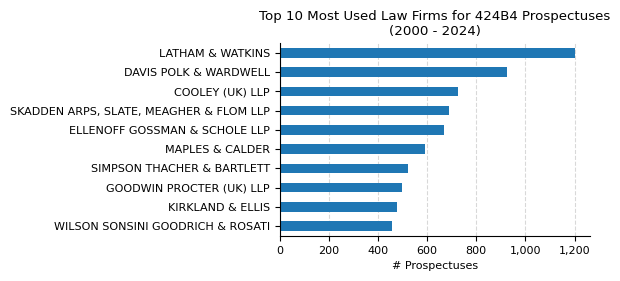

In [ ]:
df_lawfirms_pivot.sum(axis=1).sort_values(ascending=False)[:10].sort_values(
    ascending=True
).plot(kind="barh", figsize=(4, 2.5))
plt.title("Top 10 Most Used Law Firms for 424B4 Prospectuses\n(2000 - 2024)")
plt.xlabel("# Prospectuses"), plt.ylabel("")
ax = plt.gca()
ax.grid(color="gray", linestyle="dashed", alpha=0.3); ax.set_axisbelow(True); ax.yaxis.grid(False)
ax.spines["top"].set_visible(False), ax.spines["right"].set_visible(False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.show()

In [ ]:
print("Top 10 Most Used Law Firms for 424B4 Prospectuses (2000 - 2024)")
df_lawfirms_pivot.sum(axis=1) \
    .sort_values(ascending=False)[:10] \
    .to_frame() \
    .reset_index() \
    .rename(columns={0: "# Prospectuses", "lawFirmGroup": "Law Firm"})

Top 10 Most Used Law Firms for 424B4 Prospectuses (2000 - 2024)


,Law Firm,# Prospectuses
0,LATHAM & WATKINS,1201
1,DAVIS POLK & WARDWELL,927
2,COOLEY (UK) LLP,726
3,"SKADDEN ARPS, SLATE, MEAGHER & FLOM LLP",690
4,ELLENOFF GOSSMAN & SCHOLE LLP,670
5,MAPLES & CALDER,591
6,SIMPSON THACHER & BARTLETT,522
7,GOODWIN PROCTER (UK) LLP,496
8,KIRKLAND & ELLIS,479
9,WILSON SONSINI GOODRICH & ROSATI,458
